# Marketing Funnel & Conversion Analysis (Bank Marketing)
Future Interns, Task 3

In [ ]:
import pandas as pd, numpy as np
df = pd.read_csv("data/bank-full.csv", sep=";")

# ---------- Cleaning ----------
df = df.drop_duplicates().reset_index(drop=True)
df["converted"] = (df.y == "yes").astype(int)
df["engaged"]  = (df.duration >= 180).astype(int)             # 3+ minute call
df["converted_engaged"] = ((df.engaged == 1) & (df.converted == 1)).astype(int)
df["prev_contacted"] = (df.pdays != -1).astype(int)
df["age_group"] = pd.cut(df.age, [0,24,34,44,54,64,120],
        labels=["<25","25-34","35-44","45-54","55-64","65+"]).astype(str)
df["balance_band"] = pd.cut(df.balance, [-1e9,0,1000,5000,1e9],
        labels=["Negative/0","1-1000","1001-5000","5000+"]).astype(str)
df["campaign_band"] = pd.cut(df.campaign, [0,1,2,3,5,1000],
        labels=["1","2","3","4-5","6+"]).astype(str)
mo = ["jan","feb","mar","apr","may","jun","jul","aug","sep","oct","nov","dec"]
df["month_num"] = df.month.map({m:i+1 for i,m in enumerate(mo)})
df.to_csv("powerbi_ready/bank_clean.csv", index=False)


c = len(df); e = int(df.engaged.sum()); k = int(df.converted_engaged.sum())
funnel = pd.DataFrame({"stage_order":[1,2,3],
  "stage":["1. Contacted","2. Engaged (call >= 3 min)","3. Converted (subscribed)"],
  "customers":[c,e,k]})
funnel["conv_from_prev_pct"]  = (funnel.customers/funnel.customers.shift(1)*100).round(2)
funnel["conv_from_start_pct"] = (funnel.customers/c*100).round(2)
funnel["dropoff_from_prev_pct"] = (100-funnel.conv_from_prev_pct).round(2)
funnel.to_csv("powerbi_ready/funnel.csv", index=False)

def seg(col, order=None):
    g = df.groupby(col).agg(customers=("y","size"), converted=("converted","sum"),
        engaged=("engaged","sum"), avg_duration_sec=("duration","mean")).reset_index()
    g["conversion_pct"] = (g.converted/g.customers*100).round(2)
    g["engagement_pct"] = (g.engaged/g.customers*100).round(2)
    g["avg_duration_sec"] = g.avg_duration_sec.round(0)
    return g
out = {}
for col in ["job","month","contact","poutcome","education","marital","age_group",
            "balance_band","campaign_band","housing","loan"]:
    g = seg(col)
    if col=="month":
        g["month_num"]=g.month.map({m:i+1 for i,m in enumerate(mo)}); g=g.sort_values("month_num")
    else: g = g.sort_values("conversion_pct", ascending=False)
    g.to_csv(f"powerbi_ready/seg_{col}.csv", index=False); out[col]=g

overall = df.converted.mean()*100
print("rows",c,"engaged",e,"converted_engaged",k,"all_yes",df.converted.sum(),"overall%",round(overall,2))
print(funnel)
for k_ in ["job","month","contact","poutcome","age_group","balance_band","campaign_band","housing","loan","education","marital"]:
    print(out[k_][[k_,"customers","conversion_pct","engagement_pct"]].to_string(index=False)); print()
# quick converters
print("converted but <3min:", int(((df.converted==1)&(df.engaged==0)).sum()))
print("engaged but not converted:", int(((df.engaged==1)&(df.converted==0)).sum()))
print("duration<60 conv%", round(df[df.duration<60].converted.mean()*100,2), "n",(df.duration<60).sum())


rows 45211 engaged 22674 converted_engaged 4588 all_yes 5289 overall% 11.7
   stage_order                       stage  customers  conv_from_prev_pct  \
0            1                1. Contacted      45211                 NaN   
1            2  2. Engaged (call >= 3 min)      22674               50.15   
2            3   3. Converted (subscribed)       4588               20.23   

   conv_from_start_pct  dropoff_from_prev_pct  
0               100.00                    NaN  
1                50.15                  49.85  
2                10.15                  79.77  
          job  customers  conversion_pct  engagement_pct
      student        938           28.68           50.64
      retired       2264           22.79           56.58
   unemployed       1303           15.50           54.11
   management       9458           13.76           48.35
       admin.       5171           12.20           48.39
self-employed       1579           11.84           49.91
      unknown        288 

ok


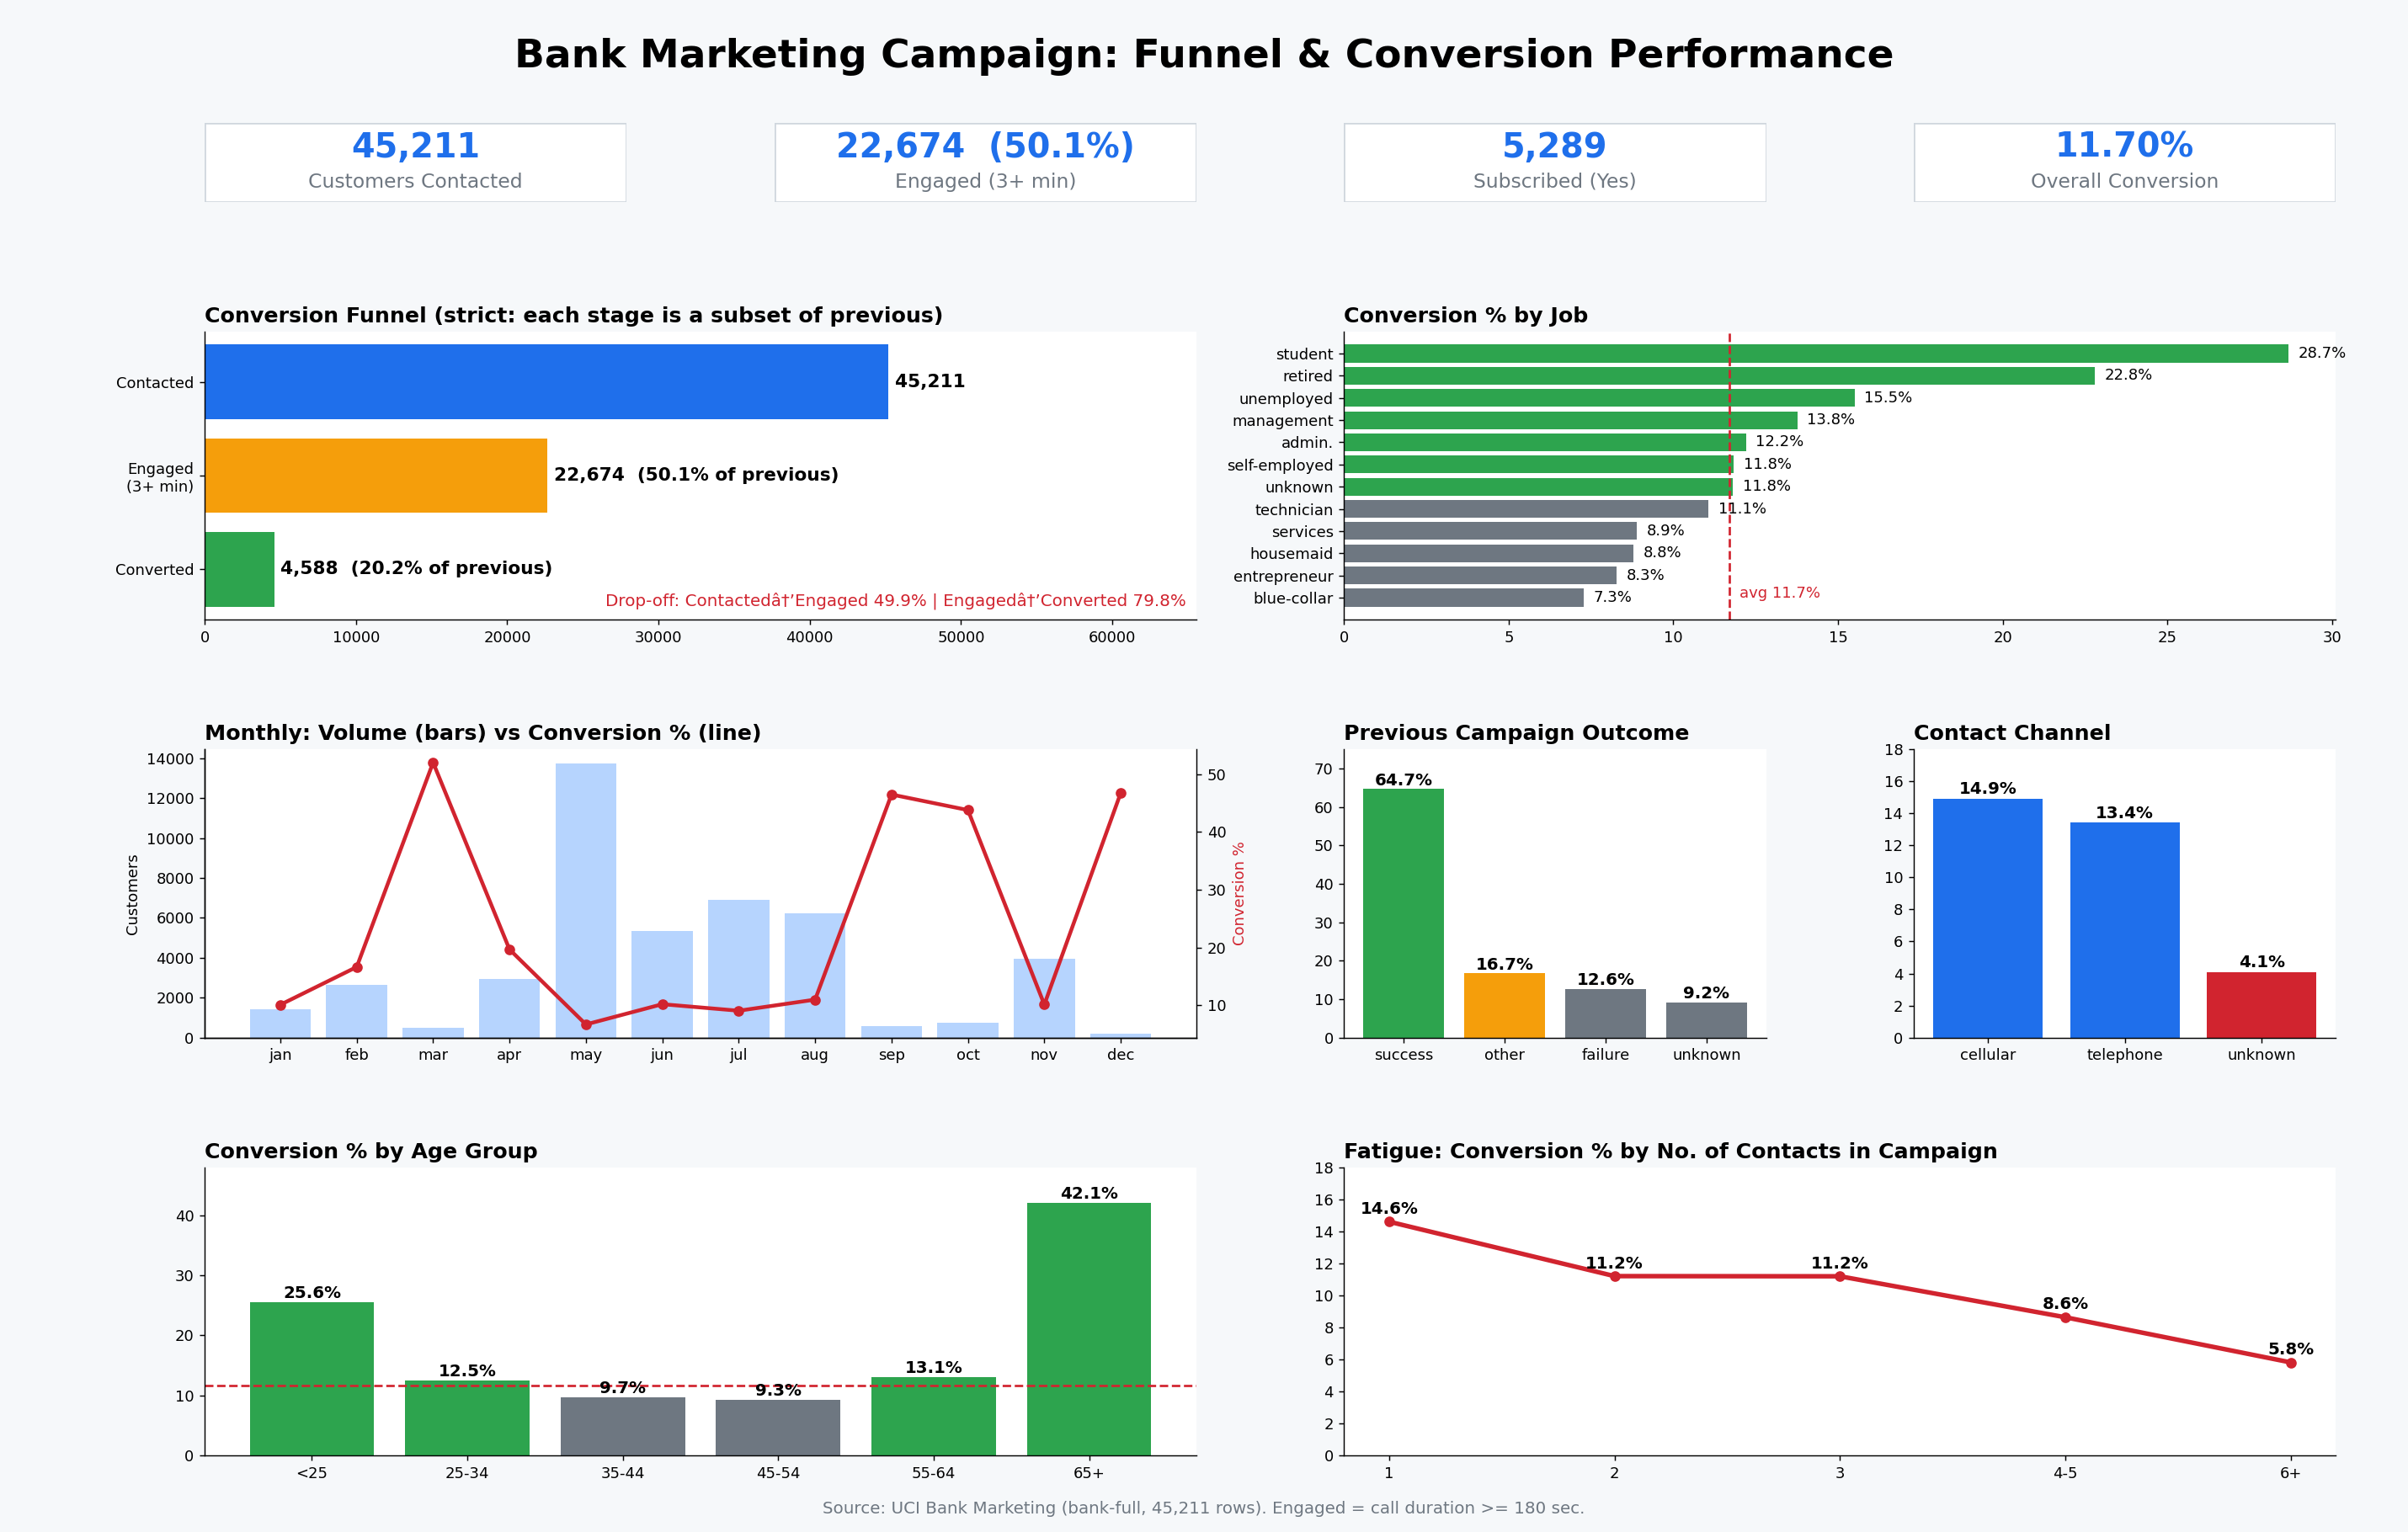

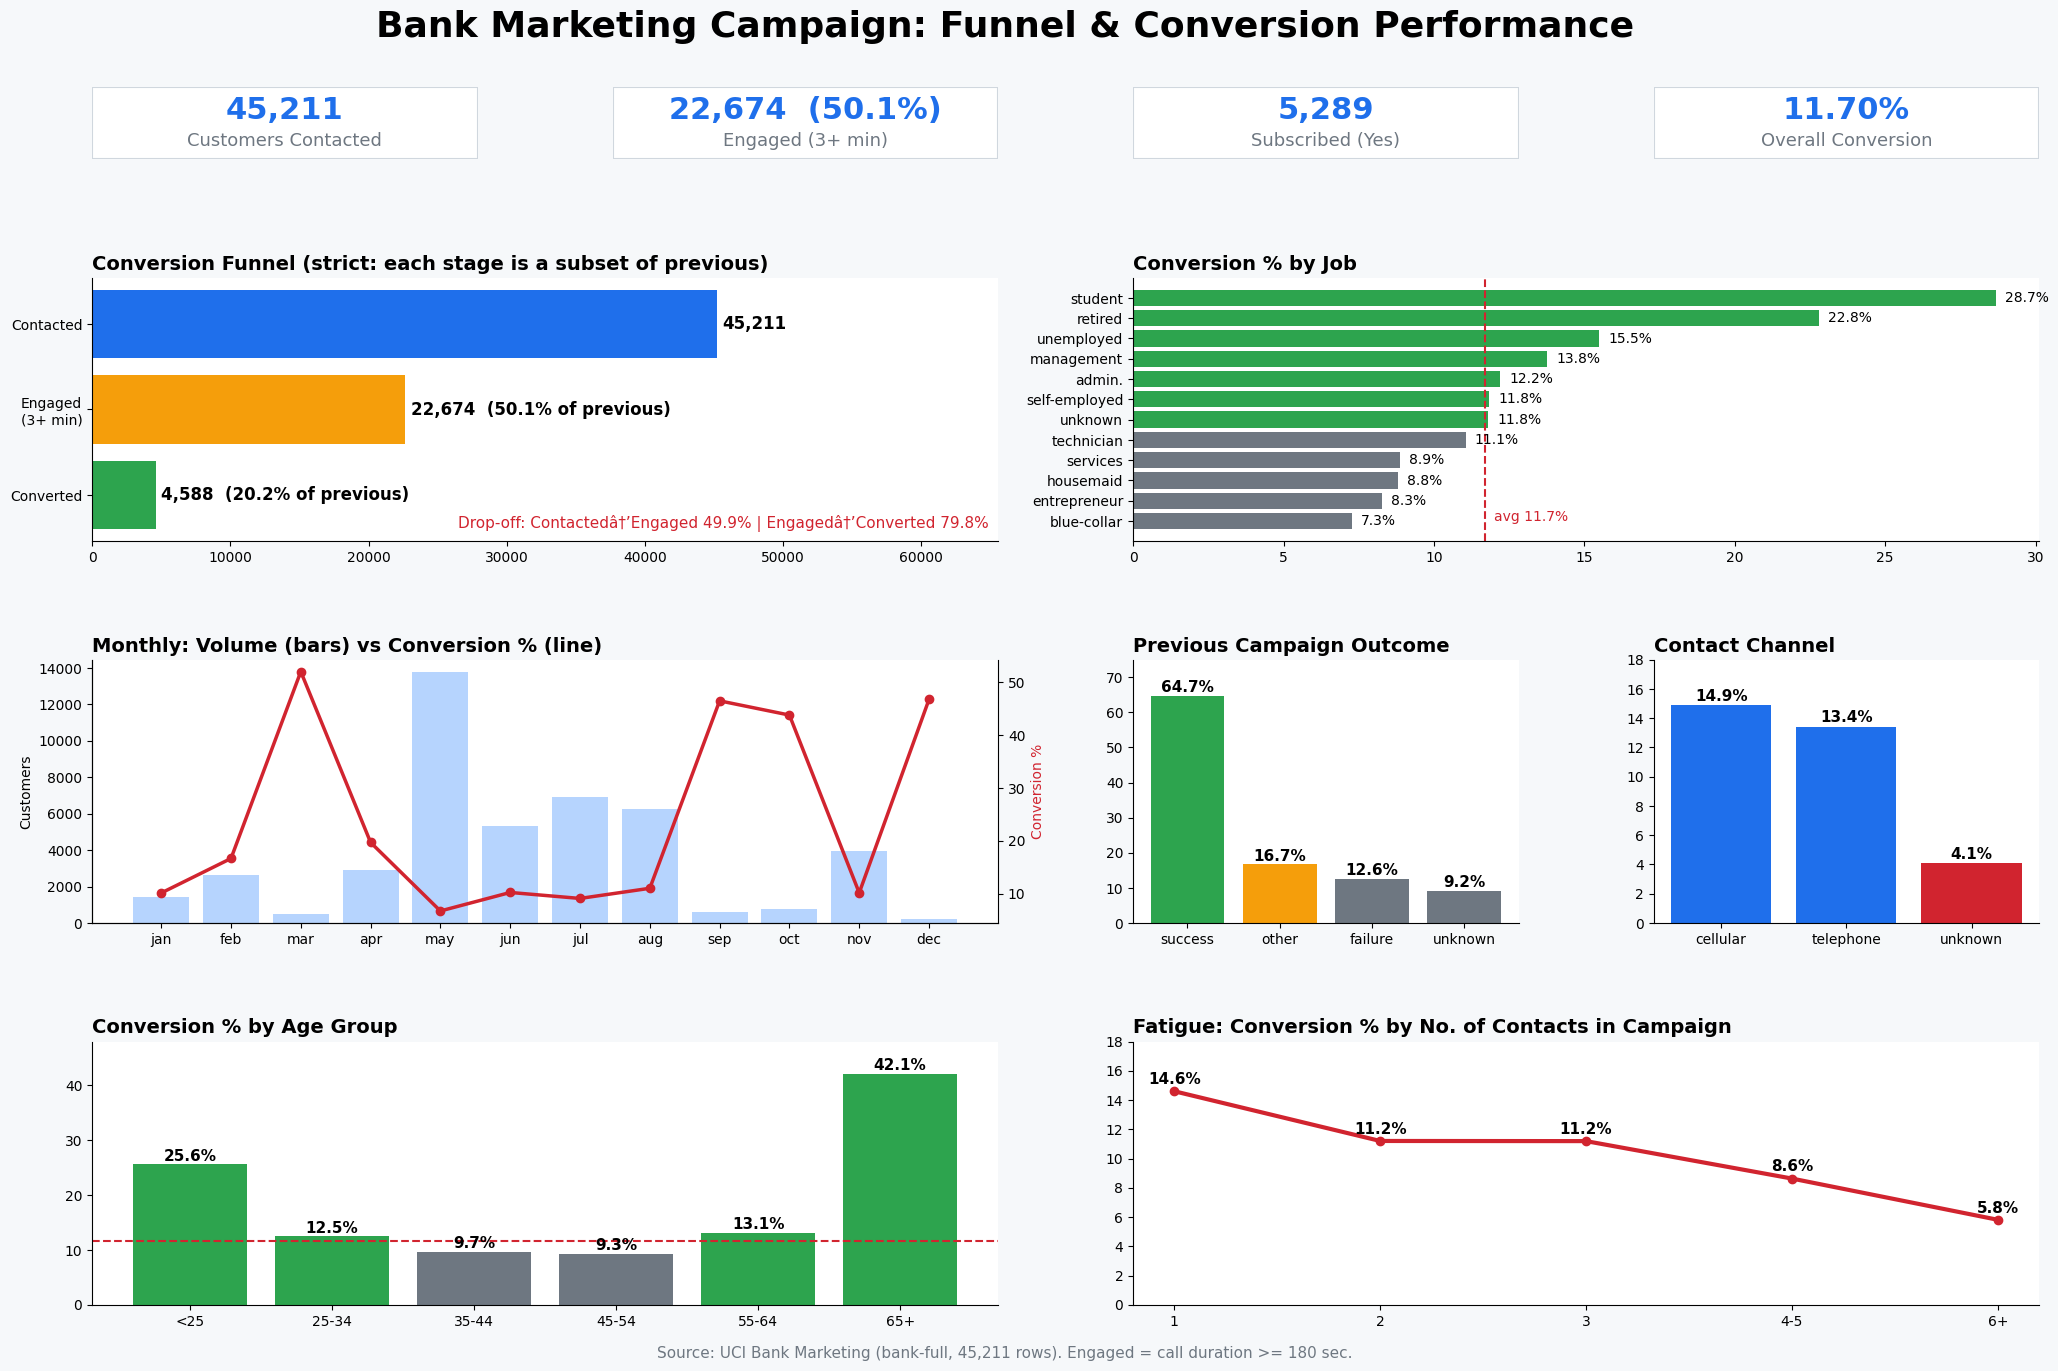

In [2]:
exec(open('dashboard.py').read())
from IPython.display import Image; Image('charts/dashboard.png')